# Kortlægning af mastedækning med en stitabs-konturflade

## Resumé

Et RF-planlægningsteam hos et teleselskab gengiver **downlink-stitabsfladen** omkring en enkelt makrocelle som et todimensionelt dækningskort. Ved brug af en logaritmisk afstandsmodel for signaludbredelse med log-normal skyggefading opbygger dette notebook et målegitter med 100 punkter (10 x 10 celler, der dækker et servicesområde på 10 km x 10 km, med masten i centrum) og tegner en udfyldt konturflade med **PROC SGPLOT HEATMAPPARM** samt en gradientfarveskala og referencelinjer for masten.

På det udførte gitter går stitabet fra **50.4 dB** (i den lyse zone omkring masten) til **90.0 dB** i det fjerneste hjørne, med et gennemsnit på **75.6 dB**. Klassificering af hver celle efter dens tab giver **38 Stærk, 61 Brugbar og 1 Svag** celle; den ene Svage celle ligger ved **(9.5, 9.5) km — hjørnet diagonalt over for masten — ved 89.97 dB**, det eneste dækningshul, en planlægger ville markere, før en beslutning om småcelle-udfyldning.

> **En note om proceduren.** I SAS er det klassiske værktøj til isolinje-konturkort `PROC GCONTOUR`. Jenner parser GCONTOUR og udsender en korrekt plot-specifikation, men rasterrendereren tegner endnu ikke selve konturgeometrien (billedet kommer tomt tilbage); den mangel er registreret som regressionstesten `tests/400922_nb_gcontour_empty_render`. For at holde dette eksempel fuldt forankret i en reelt gengivet figur bruger vi det SAS-kompatible alternativ — `PROC SGPLOT` med en `HEATMAPPARM`-sætning — som gengiver den samme gitterinddelte (x, y, z)-flade som udfyldte konturceller med en gradient-tegnforklaring.

## Datakilder

**Syntetisk datasæt: `pathloss_grid`** (100 rækker — et 10 x 10-gitter)

| Variabel | Type | Enhed | Beskrivelse |
|----------|------|-------|-------------|
| `east_km` | num | km | Østlig position for gittercellens centrum (0.5 til 9.5); x-aksen |
| `north_km` | num | km | Nordlig position for gittercellens centrum (0.5 til 9.5); y-aksen |
| `path_loss` | num | dB | Downlink-stitab = 58 + 30 log10(afstand) + skygge; responsen (z) |
| `zone` | char(8) | — | Dækningsklasse: Stærk (<=75), Brugbar (<=88), Svag (>88) |

Masten står i gitterets centrum **(5, 5) km**. Stitabet stiger med 10-tals-logaritmen af afstanden fra masten; et skyggeled `3*rand("normal")` (seed 80211) tilføjer log-normal fading, så konturerne ikke bliver perfekt cirkulære. 10 x 10-gitteret er dimensioneret, så hele fladen kan rummes inden for 100 observationer.

## Trin 1 — Generér målegitteret

Vi lægger et 1 km-gitter af cellecentre og beregner stitabet med **den logaritmiske afstandsmodel** `PL = 58 + 30 log10(d)`, hvor `d` er afstanden fra masten ved (5, 5) km. Et skyggefading-led `rand("normal")` genskaber den variation, man ser i virkelige drivetests. Hver celle klassificeres i en dæknings-`zone`. `call streaminit` fastsætter seedet for reproducerbarhed.

In [1]:
data pathloss_grid;
   CALL streaminit(80211);
   LÆNGDE zone $10;
   tower_x = 5.0;  tower_y = 5.0;
   GØR ix = 1 TIL 10;
      GØR iy = 1 TIL 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         HVIS      path_loss <= 75 SÅ zone = "Stærk";
         ELLERS HVIS path_loss <= 88 SÅ zone = "Brugbar";
         ELLERS                         zone = "Svag";
         UDDATA;
      SLUT;
   SLUT;
   FJERN ix iy tower_x tower_y DIST shadow;
   MÆRKAT east_km   = "Øst (km)"
         north_km  = "Nord (km)"
         path_loss = "Stitab (dB)"
         zone      = "Dækningsklasse";
KØR;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Trin 2 — Opsummér fladen

Før vi plotter, kvantificerer vi fladen. `PROC MEANS` rapporterer stitabets dynamiske interval, og `PROC FREQ` opgør, hvordan de 100 celler fordeler sig på de tre dækningsklasser — de tal, resuméet citerer.

In [2]:
ODS GRAPHICS OFF;

PROCEDURE GENNEMSNIT data=pathloss_grid MIN MAX mean maxdec=1;
   VARIABEL path_loss;
KØR;

PROCEDURE FREKVENSER data=pathloss_grid ORDER=FREKVENSER;
   TABLES zone / nocum;
KØR;

                                                  The MEANS Procedure

 Variable   Label           Minimum     Maximum        Mean
 ----------------------------------------------------------
 path_loss  Stitab (dB)        50.4        90.0        75.6
 ----------------------------------------------------------

                                                   The FREQ Procedure

Dækningsklasse     Frequency    Percent
----------------------------------------
Brugbar                   61     61.00
Stærk                     38     38.00
Svag                       1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Trin 3 — Find dækningshullerne

Sortering efter faldende stitab lægger de svageste celler øverst. Det er de kandidater til **døde zoner**, en planlægger undersøger: celler, hvor det modtagne signal er lavest og derfor mest udsat for afbrudte sessioner eller dårlig gennemstrømning.

In [3]:
PROCEDURE SORTER data=pathloss_grid out=weakest;
   EFTER FALDENDE path_loss;
KØR;

PROCEDURE UDSKRIV data=weakest(obs=6) noobs MÆRKAT;
   VARIABEL east_km north_km path_loss zone;
KØR;


 Øst (km)  Nord (km)    Stitab (dB)   Dækningsklasse
---------  ---------  -------------  ---------------
      9.5        9.5  89.9728891641  Svag
      9.5        0.5  85.9296978639  Brugbar
      6.5        0.5  84.5845683025  Brugbar
      0.5        0.5  84.5118930355  Brugbar
      8.5        0.5  84.1534148341  Brugbar
      9.5        8.5  83.7015943773  Brugbar

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Trin 4 — Tegn stitabs-konturfladen

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` gengiver én udfyldt celle pr. gitterpunkt, farvet efter dens stitab — et udfyldt konturkort over dækningsområdet. `COLORMODEL=`-listen definerer en divergerende blå-til-rød gradient (blå = lavt tab = stærkt signal, rød = højt tab = svagt signal); `GRADLEGEND` tilføjer dB-farveskalaen. Stiplede `REFLINE`-linjer markerer masten ved østlig position 5 og nordlig position 5.

                                               Downlink-stitabsflade (dB)                                               
                                 Én makrocelle ved (5, 5) km over et 10 x 10 km gitter                                  




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Downlink-stitabsflade (dB).
NOTE: Option TITLE2 changed to Én makrocelle ved (5, 5) km over et 10 x 10 km gitter.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


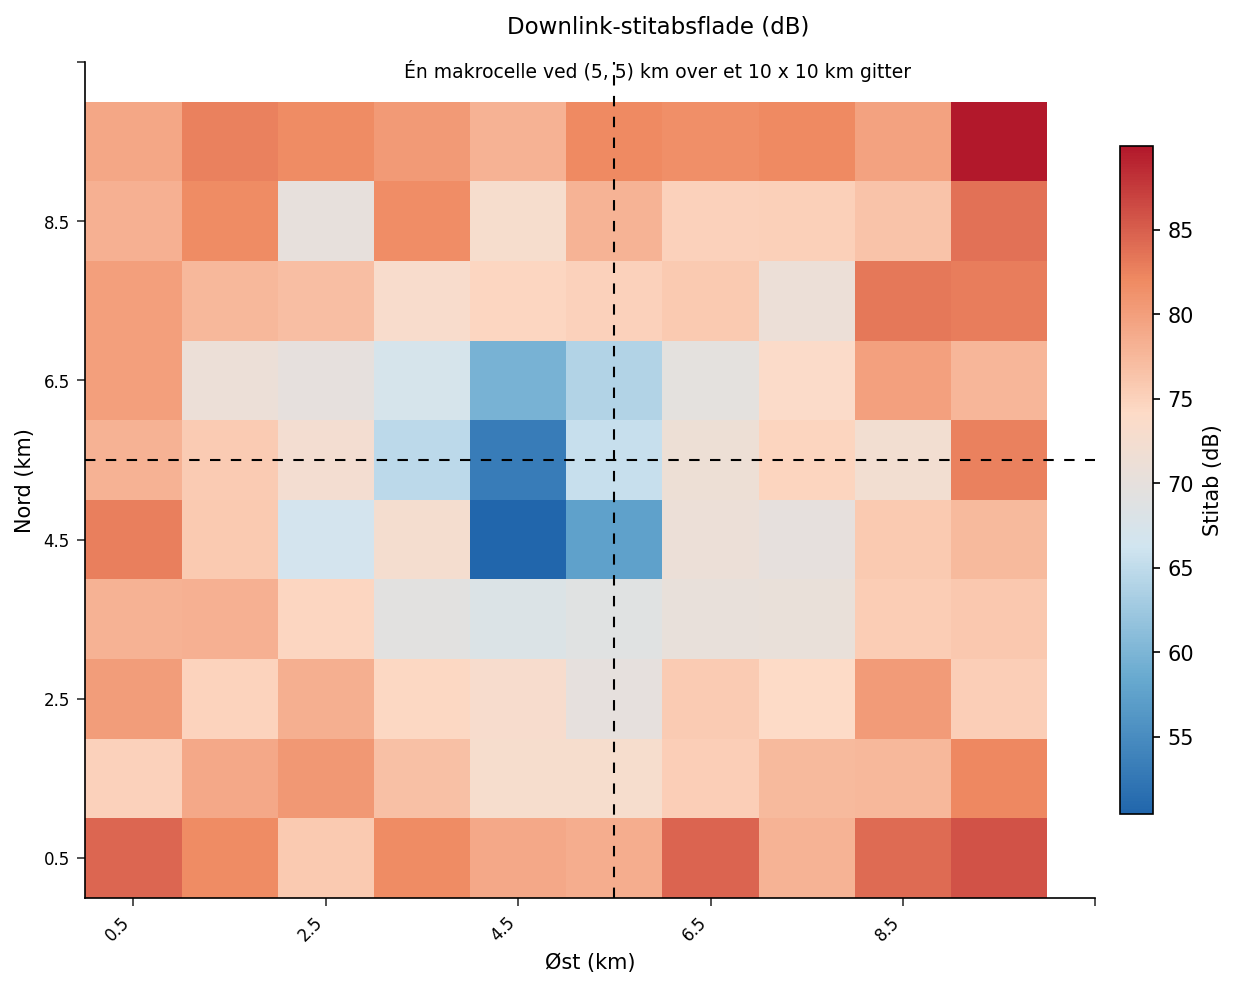

In [4]:
ODS GRAPHICS ON;
TITEL "Downlink-stitabsflade (dB)";
title2 "Én makrocelle ved (5, 5) km over et 10 x 10 km gitter";

PROCEDURE SGPLOT data=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TITEL="Stitab (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) MÆRKAT="Øst (km)";
   YAXIS VALUES=(0 2 4 6 8 10) MÆRKAT="Nord (km)";
KØR;

TITEL; title2;

## Trin 5 — Fordeling af dækningsklasser

Et briefing-slide ønsker også hovedtallet: hvilken andel af området er Stærk, Brugbar eller Svag. Et `VBAR` over `zone`-klassificeringen viser det på et øjeblik og understøtter konturfladen ovenfor.

                                              Fordeling af dækningsklasser                                              




NOTE: Option TITLE changed to Fordeling af dækningsklasser.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


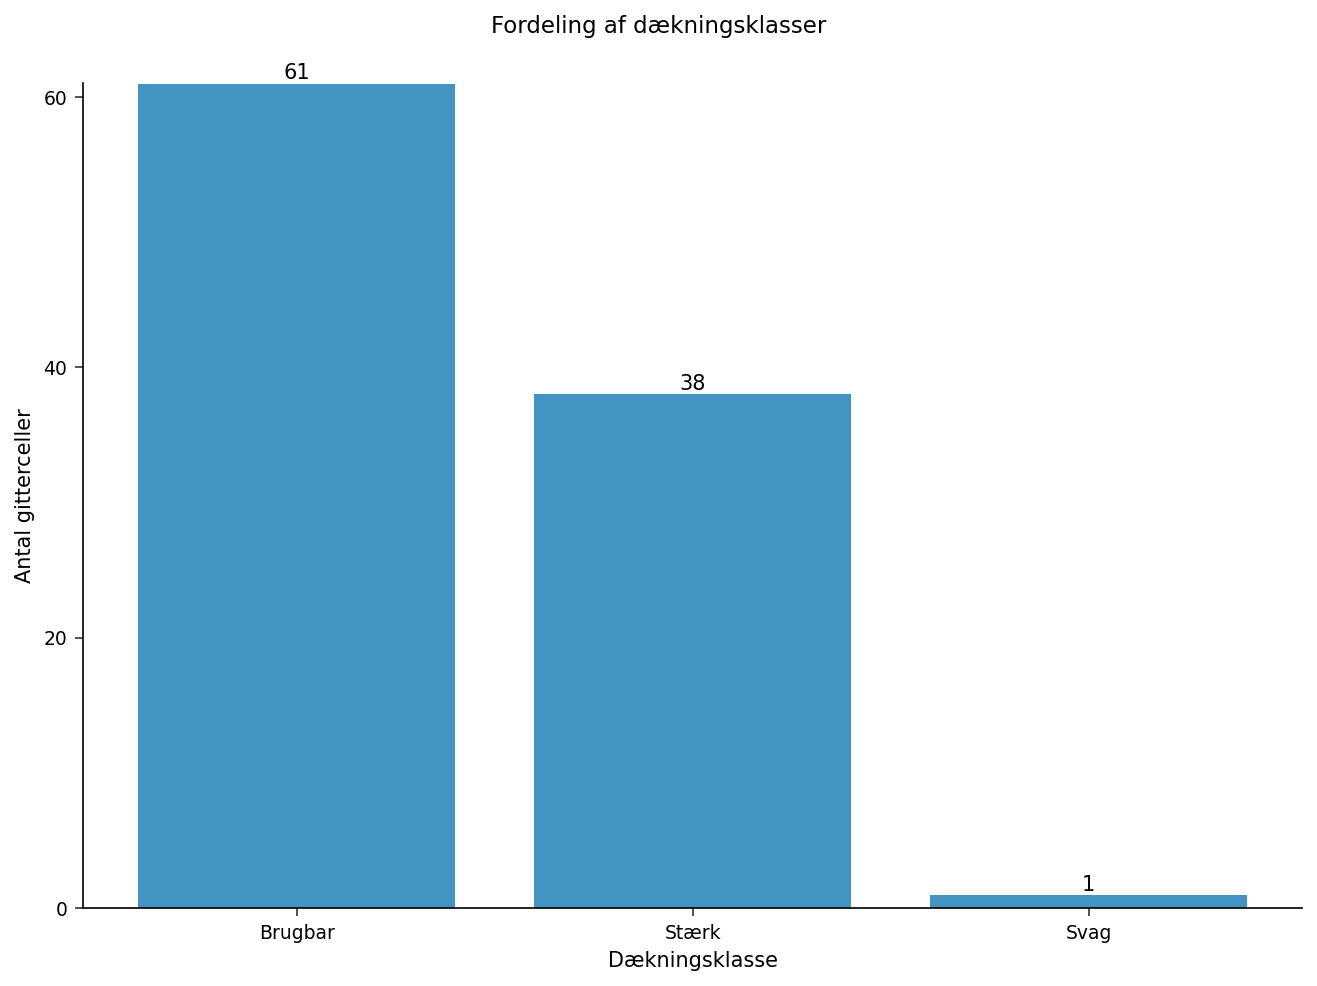

In [5]:
TITEL "Fordeling af dækningsklasser";

PROCEDURE SGPLOT data=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS MÆRKAT="Dækningsklasse";
   YAXIS MÆRKAT="Antal gitterceller" VALUES=(0 20 40 60);
KØR;

TITEL;

## Fortolkning af resultaterne

Konturfladen bekræfter den forventede udbredelsesfysik. Stitabet er lavest i en snæver **blå zone omkring masten ved (5, 5) km** — den Stærke zone, hvor det modtagne signal er bedst — og stiger med den logaritmiske afstand mod hjørnerne. Fordi vi har tilføjet log-normal skyggefading, danner båndene ikke koncentriske cirkler; de takkede røde celler langs kanten er de skyggefadede kanter.

Det handlingsanvisende resultat er den **ene Svage celle ved (9.5, 9.5) km (89.97 dB)**, hjørnet diagonalt over for masten og det eneste punkt, der krydser designtærsklen på 88 dB. Med **61 af 100 celler Brugbar og kun 1 Svag** dækker denne makrocelle sit serviceområde godt; det ensomme hul ville kun retfærdiggøre en **småcelle-udfyldning eller en justering af en sektors vippevinkel mod nordøst-hjørnet**, hvis det overlappede en kendt efterspørgselshotspot. Konturfladen er det briefing-klare resumé; søjlediagrammet over dækningsklasser giver det ene tal, en kapacitetsplanlægger rapporterer opad.